# Machine Learning Capstone Project: Review 1
## Classification Analysis (Maternal Health Risk & Cardiotocography CTG Datasets)
**Datasets:**  
1. Maternal Health Risk Dataset (`Maternal Health Risk Data Set.csv`)  
2. Cardiotocography Dataset (`CTG.xls` Sheet: `Raw Data`)  


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Classification Algorithms
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42


##  1.  Maternal Health Risk Dataset Audit & EDA

In [13]:
df_clf = pd.read_csv(r'C:\Users\lakshanya\OneDrive\Desktop\ml_capstone\Ember-Storm\data\Maternal Health Risk Data Set.csv')

print("="*60)
print(f"Track A Dataset Shape: {df_clf.shape[0]} rows, {df_clf.shape[1]} columns")
print("="*60)
display(df_clf.head())

print("Target Class Distribution ('RiskLevel'):")
display(df_clf['RiskLevel'].value_counts())


Track A Dataset Shape: 1014 rows, 7 columns


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


Target Class Distribution ('RiskLevel'):


RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

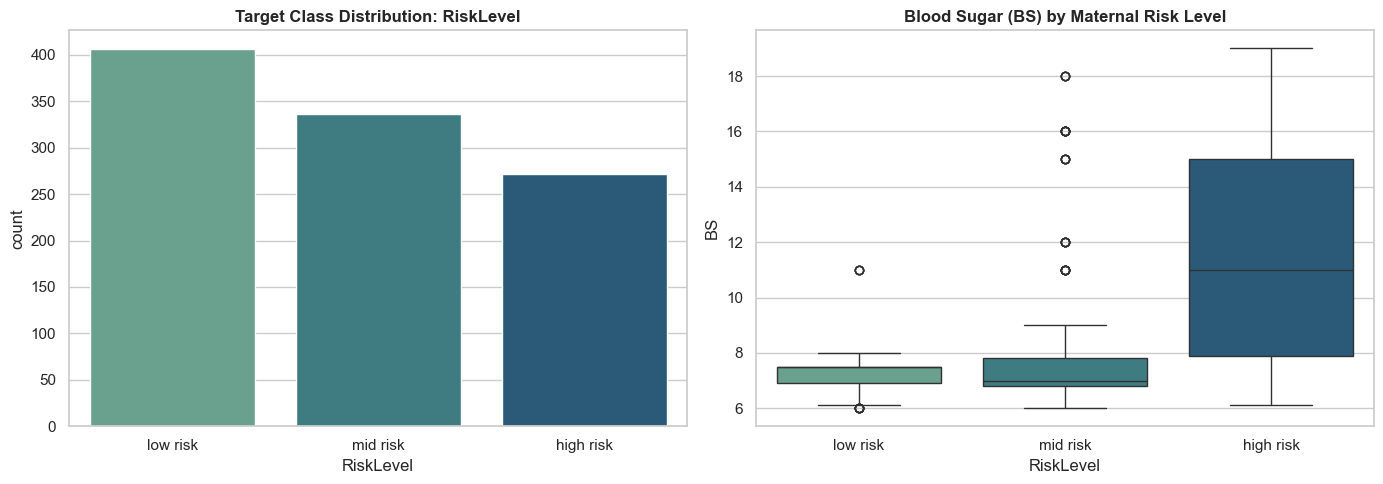

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_clf, x='RiskLevel', order=['low risk', 'mid risk', 'high risk'], ax=axes[0], palette='crest')
axes[0].set_title('Target Class Distribution: RiskLevel', fontsize=12, fontweight='bold')

sns.boxplot(data=df_clf, x='RiskLevel', y='BS', order=['low risk', 'mid risk', 'high risk'], ax=axes[1], palette='crest')
axes[1].set_title('Blood Sugar (BS) by Maternal Risk Level', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


##  2. Preprocessing & Feature Engineering

In [15]:
label_enc = LabelEncoder()
df_clf['RiskLevel_Code'] = label_enc.fit_transform(df_clf['RiskLevel'])

# Feature Engineering: Mean Arterial Pressure (MAP)
df_clf['MAP'] = (df_clf['SystolicBP'] + 2 * df_clf['DiastolicBP']) / 3.0

features_c = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'MAP']
X_c = df_clf[features_c]
y_c = df_clf['RiskLevel_Code']

# Stratified Train-Test Split (80:20)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=RANDOM_STATE, stratify=y_c
)

# Standard Scaling fitted strictly on training data
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

print(f"Stratified Training shape: {X_train_c.shape} | Test shape: {X_test_c.shape}")


Stratified Training shape: (811, 7) | Test shape: (203, 7)


##  3.Model Implementations

#### 3.1 K-Nearest Neighbors (KNN) 

In [16]:
best_score_knn = 0
best_params_knn = {}

for p in [1, 2]:
    for k in range(1, 15, 2):
        knn_c = KNeighborsClassifier(n_neighbors=k, p=p, weights='distance')
        score = cross_val_score(knn_c, X_train_c_scaled, y_train_c, cv=5, scoring='f1_weighted').mean()
        if score > best_score_knn:
            best_score_knn = score
            best_params_knn = {'n_neighbors': k, 'p': p}

best_knn_clf = KNeighborsClassifier(n_neighbors=best_params_knn['n_neighbors'], p=best_params_knn['p'], weights='distance')
best_knn_clf.fit(X_train_c_scaled, y_train_c)
y_pred_knn_c = best_knn_clf.predict(X_test_c_scaled)

acc_knn = accuracy_score(y_test_c, y_pred_knn_c)
prec_knn = precision_score(y_test_c, y_pred_knn_c, average='weighted')
rec_knn = recall_score(y_test_c, y_pred_knn_c, average='weighted')
f1_knn = f1_score(y_test_c, y_pred_knn_c, average='weighted')

print(f"KNN Classifier (Params={best_params_knn}): Accuracy = {acc_knn:.4f} | F1 = {f1_knn:.4f}")


KNN Classifier (Params={'n_neighbors': 3, 'p': 1}): Accuracy = 0.8079 | F1 = 0.8074


#### 3.2 Logistic Regression (Multi-class)

In [18]:
log_reg = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)
log_reg.fit(X_train_c_scaled, y_train_c)
y_pred_log = log_reg.predict(X_test_c_scaled)

acc_log = accuracy_score(y_test_c, y_pred_log)
prec_log = precision_score(y_test_c, y_pred_log, average='weighted')
rec_log = recall_score(y_test_c, y_pred_log, average='weighted')
f1_log = f1_score(y_test_c, y_pred_log, average='weighted')

print(f"Logistic Regression: Accuracy = {acc_log:.4f} | F1 = {f1_log:.4f}")


Logistic Regression: Accuracy = 0.6207 | F1 = 0.6039


#### 3.3 Decision Tree Classifier (`GridSearchCV`)

In [19]:
dt_c_param_grid = {'max_depth': [3, 5, 10, 15], 'min_samples_split': [2, 5]}
dt_c_grid = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), dt_c_param_grid, cv=5, scoring='f1_weighted')
dt_c_grid.fit(X_train_c, y_train_c)

best_dt_c = dt_c_grid.best_estimator_
y_pred_dt_c = best_dt_c.predict(X_test_c)

acc_dt_c = accuracy_score(y_test_c, y_pred_dt_c)
prec_dt_c = precision_score(y_test_c, y_pred_dt_c, average='weighted')
rec_dt_c = recall_score(y_test_c, y_pred_dt_c, average='weighted')
f1_dt_c = f1_score(y_test_c, y_pred_dt_c, average='weighted')

print(f"Decision Tree Classifier: Best Params = {dt_c_grid.best_params_} | Accuracy = {acc_dt_c:.4f} | F1 = {f1_dt_c:.4f}")


Decision Tree Classifier: Best Params = {'max_depth': 15, 'min_samples_split': 2} | Accuracy = 0.8424 | F1 = 0.8439


#### 3.4 Support Vector Classifier (SVC RBF Kernel)

In [20]:
svc_c = SVC(kernel='rbf', C=10.0, random_state=RANDOM_STATE)
svc_c.fit(X_train_c_scaled, y_train_c)
y_pred_svc = svc_c.predict(X_test_c_scaled)

acc_svc = accuracy_score(y_test_c, y_pred_svc)
prec_svc = precision_score(y_test_c, y_pred_svc, average='weighted')
rec_svc = recall_score(y_test_c, y_pred_svc, average='weighted')
f1_svc = f1_score(y_test_c, y_pred_svc, average='weighted')

print(f"Support Vector Classifier (SVC): Accuracy = {acc_svc:.4f} | F1 = {f1_svc:.4f}")


Support Vector Classifier (SVC): Accuracy = 0.7044 | F1 = 0.6942


#### 3.5 Naive Bayes Classifier (`GaussianNB`)

In [21]:
nb_clf = GaussianNB()
nb_clf.fit(X_train_c_scaled, y_train_c)
y_pred_nb = nb_clf.predict(X_test_c_scaled)

acc_nb = accuracy_score(y_test_c, y_pred_nb)
prec_nb = precision_score(y_test_c, y_pred_nb, average='weighted')
rec_nb = recall_score(y_test_c, y_pred_nb, average='weighted')
f1_nb = f1_score(y_test_c, y_pred_nb, average='weighted')

print(f"Gaussian Naive Bayes: Accuracy = {acc_nb:.4f} | F1 = {f1_nb:.4f}")


Gaussian Naive Bayes: Accuracy = 0.6010 | F1 = 0.5583


## Track A Consolidated Summary Table (Maternal Health Risk Dataset)

In [22]:
track_a_results = [
    # Person 1
    { 'Algorithm': 'K-Nearest Neighbors Classifier', 'Accuracy': acc_knn, 'Precision': prec_knn, 'Recall': rec_knn, 'Weighted F1': f1_knn},
    # Person 2
    { 'Algorithm': 'Logistic Regression', 'Accuracy': acc_log, 'Precision': prec_log, 'Recall': rec_log, 'Weighted F1': f1_log},
    {'Algorithm': 'Decision Tree Classifier (Tuned)', 'Accuracy': acc_dt_c, 'Precision': prec_dt_c, 'Recall': rec_dt_c, 'Weighted F1': f1_dt_c},
    { 'Algorithm': 'Support Vector Classifier (SVC)', 'Accuracy': acc_svc, 'Precision': prec_svc, 'Recall': rec_svc, 'Weighted F1': f1_svc},
    { 'Algorithm': 'Gaussian Naive Bayes', 'Accuracy': acc_nb, 'Precision': prec_nb, 'Recall': rec_nb, 'Weighted F1': f1_nb},

]

summary_a_df = pd.DataFrame(track_a_results).sort_values(by='Weighted F1', ascending=False).reset_index(drop=True)
display(summary_a_df.style.highlight_max(subset=['Accuracy', 'Weighted F1'], color='lightgreen').format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'Weighted F1': '{:.4f}'
}))


,Algorithm,Accuracy,Precision,Recall,Weighted F1
0,Decision Tree Classifier (Tuned),0.8424,0.8583,0.8424,0.8439
1,K-Nearest Neighbors Classifier,0.8079,0.8089,0.8079,0.8074
2,Support Vector Classifier (SVC),0.7044,0.7183,0.7044,0.6942
3,Logistic Regression,0.6207,0.6086,0.6207,0.6039
4,Gaussian Naive Bayes,0.6010,0.5780,0.6010,0.5583


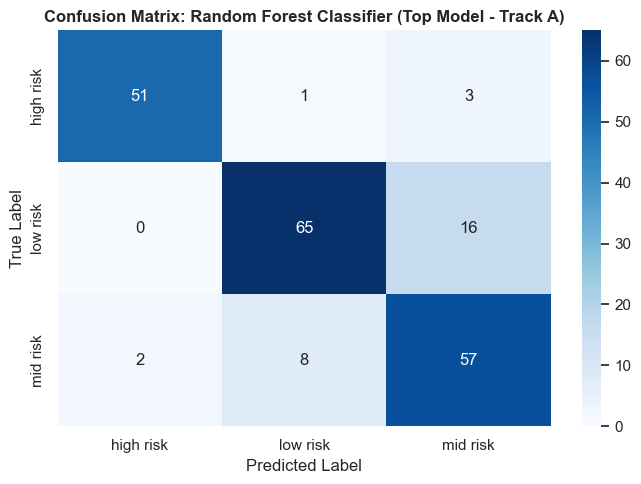

In [14]:
cm_best = confusion_matrix(y_test_c, y_pred_rf_c)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=label_enc.classes_, yticklabels=label_enc.classes_)
plt.title('Confusion Matrix: Random Forest Classifier (Top Model - Track A)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()
